# Oregon Income Tax Return Types: Data Analysis Final Project

**Created by:** Dinh Nguyen
**For Class:** CS 410 Data With Python

---

## 1. Dataset Selection and Initial Exploration

**Dataset Chosen:** Oregon Individual Income Tax Statistics by County

**Source:** [Oregon.Gov Open Data Portal](https://data.oregon.gov/Administrative/Selected-types-of-Oregon-Personal-Income-Tax-retur/hp3d-wwbv)

[Download .csv data](https://data.oregon.gov/api/views/v2yt-n6gs/rows.csv?date=20250604&accessType=DOWNLOAD)

**Description:**
This dataset contains information about Oregon state income tax returns, categorized by county and tax year. It includes counts and percentages of different return types (single, joint, etc.), as well as financial summaries such as: adjusted gross income, taxable income, tax amounts, credits...

The dataset explores income tax trends and characteristics across Oregon counties and over different years.


In [38]:
# import pandas as pd
import pandas as pd
# Load the Oregon income tax data
df_tax = pd.read_csv('Historical_personal_income_tax_return_statistics_by_county_and_tax_year_20250604.csv')
df_tax.head()

,Row_Id,Date of Update,Tax Year,County,Number of Returns,Total Number of Exemptions (thousands of dollars),Total Adjusted Gross Income (thousands of dollars),Total Oregon Adjustments: Additions (thousands of dollars),Total Oregon Adjustments: Federal Tax Subtraction (thousands of dollars),Total Oregon Adjustments: Other Subtractions (thousands of dollars),...,"Full Year Returns: Total Wages, Salaries, Tips (thousands of dollars)",Full Year Returns: Total Taxable Dividends and Interest (thousands of dollars),Full Year Returns: Total Business Income (thousands of dollars),Full Year Returns: Total Capital Gains (thousands of dollars),Full Year Returns: Total Taxable Pensions (thousands of dollars),"Full Year Returns: Total Schedule E Income (thousands of dollars, this includes: rental real estate, royalties, partnerships, S corporations, and trusts)",Full Year Returns: Total Farm Income (thousands of dollars),"Full Year Returns: Total All Other Income (thousands of dollars, this includes: taxable state income tax refunds, alimony received, unemployment compensation, and other income)",Full Year Returns: Total Adjustments (thousands of dollars),Exception Notes
0,1,"Jul 01, 2006",2004,Baker,6422,13033,203292,754,8407,15473,...,133398,11320,4973,17568,38711,7760,-5995,-1881,4396,NaN
1,2,"Jul 01, 2006",2004,Benton,30315,55918,1455653,4671,54620,75935,...,965346,78108,48777,105807,199504,53271,-5159,17025,24858,NaN
2,3,"Jul 01, 2006",2004,California,23369,45216,749888,7790,15309,39651,...,96553,13387,7188,49114,16678,43368,-348,1609,2401,NaN
3,4,"Jul 01, 2006",2004,Clackamas,143293,295424,8461478,22594,286526,325348,...,5827189,318337,321408,584175,840571,543098,-29642,117517,143587,NaN
4,5,"Jul 01, 2006",2004,Clark Co WA,54419,132860,2066272,2952,82112,44458,...,68966,5348,2594,5228,6730,8946,-2,2316,1360,NaN


**Initial Questions / Areas of Interest:**
1. How do the types of tax returns filed (single, joint, etc.) vary by county?
2. Are there trends in average adjusted gross income?
3. Are there any suspicious data that might need further investigation?


## 2. Data Import and Cleaning

We import the data using pandas and perform an initial examination to identify missing values, incorrect types, and potential outliers.
We also try to format the column namings for a better uniformed styling.

In [39]:
# Display data info
print("\n\nData info:")
df_tax.info()
# Describe the data
print("\n\nData short description:")
df_tax.describe()



Data info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 738 entries, 0 to 737
Data columns (total 55 columns):
 #   Column                                                                                                                                                                            Non-Null Count  Dtype  
---  ------                                                                                                                                                                            --------------  -----  
 0   Row_Id                                                                                                                                                                            738 non-null    int64  
 1   Date of Update                                                                                                                                                                    738 non-null    object 
 2   Tax Year                                         

,Row_Id,Tax Year,Number of Returns,Total Number of Exemptions (thousands of dollars),Total Adjusted Gross Income (thousands of dollars),Total Oregon Adjustments: Additions (thousands of dollars),Total Oregon Adjustments: Federal Tax Subtraction (thousands of dollars),Total Oregon Adjustments: Other Subtractions (thousands of dollars),Total Deductions (thousands of dollars),Total Taxable Income (thousands of dollars),...,Full Year Returns: Total Adjusted Gross Income (thousands of dollars),"Full Year Returns: Total Wages, Salaries, Tips (thousands of dollars)",Full Year Returns: Total Taxable Dividends and Interest (thousands of dollars),Full Year Returns: Total Business Income (thousands of dollars),Full Year Returns: Total Capital Gains (thousands of dollars),Full Year Returns: Total Taxable Pensions (thousands of dollars),"Full Year Returns: Total Schedule E Income (thousands of dollars, this includes: rental real estate, royalties, partnerships, S corporations, and trusts)",Full Year Returns: Total Farm Income (thousands of dollars),"Full Year Returns: Total All Other Income (thousands of dollars, this includes: taxable state income tax refunds, alimony received, unemployment compensation, and other income)",Full Year Returns: Total Adjustments (thousands of dollars)
count,738,738,738,738,738,738,738,738,738,738,...,738,738,738,738,738,738,738,738,738,738
mean,370,"2,012","47,056","93,105","2,737,934","12,319","98,727","153,399","415,872","2,167,884",...,"2,539,759","1,688,790","97,456","87,266","168,884","351,730","170,985","-6,283","22,335","41,404"
std,213,5,"70,981","134,359","5,078,501","20,883","175,011","225,248","701,737","4,117,097",...,"5,030,262","3,466,471","193,041","179,682","378,394","566,940","357,248","6,955","68,171","79,010"
min,1,"2,004",508,983,"13,569",28,567,"1,420","3,402","11,476",...,"13,473","10,168",596,"-4,856",295,"2,745","-60,893","-41,940","-66,414",301
25%,185,"2,008","9,038","18,242","332,518","1,269","13,364","26,132","62,134","252,046",...,"190,390","128,518","9,035","4,722","12,777","31,226","9,988","-9,174","-2,508","3,586"
50%,370,"2,012","21,634","43,210","967,382","3,960","36,262","64,220","177,608","738,357",...,"626,640","389,968","24,548","20,950","38,226","117,744","36,376","-4,702","2,282","11,972"
75%,554,"2,017","46,240","93,094","2,203,037","10,637","86,877","158,284","361,752","1,748,763",...,"1,944,730","1,297,500","70,483","61,675","114,969","351,468","108,955","-1,173","18,948","28,947"
max,738,"2,021","399,530","676,968","35,917,968","143,709","1,097,638","1,267,954","3,500,718","30,778,004",...,"35,177,017","23,051,953","1,153,615","1,351,902","3,439,700","3,487,844","2,319,498","6,681","846,061","484,916"


In [40]:
# Check for missing values
df_tax.isnull().sum()

Row_Id                                                                                                                                                                                0
Date of Update                                                                                                                                                                        0
Tax Year                                                                                                                                                                              0
County                                                                                                                                                                                0
Number of Returns                                                                                                                                                                     0
Total Number of Exemptions (thousands of dollars)                               

### Cleaning Step 1: Handling Missing Values
There are some missing values, especially in columns not relevant to our main analysis (e.g., `exception_notes`). For this analysis, we will drop rows with missing values in critical columns (such as tax year, county, AGI, and return types), but retain rows with missing `exception_notes`.

In [41]:
# Format column names to more pythonic standards
df_tax.columns = (
    df_tax.columns
    .str.strip()  # Remove leading/trailing whitespace
    .str.lower()  # Convert to lowercase
    .str.replace(r'[^\w\s]', '', regex=True)  # Remove special characters
    .str.replace(r'\s+', '_', regex=True)  # Replace spaces with underscores
)

# Print the updated column names
print("Updated column names:", df_tax.columns.tolist())

Updated column names: ['row_id', 'date_of_update', 'tax_year', 'county', 'number_of_returns', 'total_number_of_exemptions_thousands_of_dollars', 'total_adjusted_gross_income_thousands_of_dollars', 'total_oregon_adjustments_additions_thousands_of_dollars', 'total_oregon_adjustments_federal_tax_subtraction_thousands_of_dollars', 'total_oregon_adjustments_other_subtractions_thousands_of_dollars', 'total_deductions_thousands_of_dollars', 'total_taxable_income_thousands_of_dollars', 'total_gross_tax_thousands_of_dollars', 'total_credits_thousands_of_dollars', 'total_net_tax_thousands_of_dollars', 'average_number_of_exemptions', 'average_adjusted_gross_income_dollars', 'average_oregon_adjustments_additions_dollars', 'average_oregon_adjustments_federal_tax_subtraction_dollars', 'average_oregon_adjustments_other_subtractions_dollars', 'average_deductions_dollars', 'average_taxable_income_dollars', 'average_gross_tax_dollars', 'average_credits_dollars', 'average_net_tax_dollars', 'tax_as_percen

In [42]:
# Set critical columns for analysis, only clean what is necessary
critical_cols = [
    'tax_year', 
    'county', 
    'number_of_returns', 
    'total_adjusted_gross_income_thousands_of_dollars', 
    'return_type_single_number', 
    'return_type_joint_number'
]
# Drop rows with missing values in critical columns
df_tax = df_tax.dropna(subset=critical_cols)
# Reset index after dropping rows
df_tax = df_tax.reset_index(drop=True)
# Display the updated DataFrame info
df_tax.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 735 entries, 0 to 734
Data columns (total 55 columns):
 #   Column                                                                                                                                                                    Non-Null Count  Dtype  
---  ------                                                                                                                                                                    --------------  -----  
 0   row_id                                                                                                                                                                    735 non-null    int64  
 1   date_of_update                                                                                                                                                            735 non-null    object 
 2   tax_year                                                                                      

### Cleaning Step 2: Remove Duplicates

In [43]:
df_tax = df_tax.drop_duplicates()
df_tax.shape

(735, 55)

### Cleaning Step 3: Standardize Column Names
Column names may have whitespace or inconsistent casing that will need to clean up.

In [44]:
df_tax.columns = df_tax.columns.str.strip().str.lower().str.replace(' ', '_')
# show all the columns
print("Final column names:", df_tax.columns.tolist())

Final column names: ['row_id', 'date_of_update', 'tax_year', 'county', 'number_of_returns', 'total_number_of_exemptions_thousands_of_dollars', 'total_adjusted_gross_income_thousands_of_dollars', 'total_oregon_adjustments_additions_thousands_of_dollars', 'total_oregon_adjustments_federal_tax_subtraction_thousands_of_dollars', 'total_oregon_adjustments_other_subtractions_thousands_of_dollars', 'total_deductions_thousands_of_dollars', 'total_taxable_income_thousands_of_dollars', 'total_gross_tax_thousands_of_dollars', 'total_credits_thousands_of_dollars', 'total_net_tax_thousands_of_dollars', 'average_number_of_exemptions', 'average_adjusted_gross_income_dollars', 'average_oregon_adjustments_additions_dollars', 'average_oregon_adjustments_federal_tax_subtraction_dollars', 'average_oregon_adjustments_other_subtractions_dollars', 'average_deductions_dollars', 'average_taxable_income_dollars', 'average_gross_tax_dollars', 'average_credits_dollars', 'average_net_tax_dollars', 'tax_as_percent_

### Cleaning Step 4: Data Types
We'll convert relevant columns to numeric types where necessary.

In [45]:
numeric_cols = [col for col in df_tax.columns if '_num' in col or '_k' in col or '_pct' in col or 'avg_' in col or 'tax_year' in col]
for col in numeric_cols:
    df_tax[col] = pd.to_numeric(df_tax[col], errors='coerce')
# Check types
df_tax[numeric_cols].dtypes

tax_year                                             int64
total_number_of_exemptions_thousands_of_dollars      int64
average_number_of_exemptions                       float64
return_type_single_number                          float64
return_type_joint_number                           float64
return_type_separate_number                        float64
return_type_head_household_number                  float64
return_type_itemized_number                          int64
return_type_fullyear_number                        float64
return_type_partyear_number                        float64
return_type_nonresident_number                     float64
full_year_returns_number_of_returns                float64
dtype: object

### Cleaning Step 5: Removing Un-named Counties
There are counties with name Other that will be removed for cleaner and clear data.

In [46]:
# Check how many "Other" records exist
other_count = df_tax[df_tax['county'] == 'Other'].shape[0]
total_count = df_tax.shape[0]
print(f"'Other' records: {other_count} out of {total_count} ({other_count/total_count*100:.2f}%)")

# remove "Other" records
df_tax = df_tax[df_tax['county'] != 'Other']
# Reset index after filtering
df_tax = df_tax.reset_index(drop=True)

'Other' records: 18 out of 735 (2.45%)


### Cleaning Step 5: Removing None Oregon Counties
Upon learning about the data, there are some counties that appear but are not part of Oregon. They will be removed in here.

In [47]:
# Showing all counties in the dataset
print("\nCounties in the dataset:")
print(df_tax['county'].unique())

# Remove California county from data
df_tax = df_tax[df_tax['county'] != 'California']
# Remove Other Washington
df_tax = df_tax[df_tax['county'] != 'Other Washington']
# Remove Idaho county
df_tax = df_tax[df_tax['county'] != 'Idaho']
# Remove Clark Co WA county
df_tax = df_tax[df_tax['county'] != 'Clark Co WA']

# Reset index after filtering
df_tax = df_tax.reset_index(drop=True)

# Showing all counties in the dataset after clean up
print("\nCounties in the dataset after clean up:")
print(df_tax['county'].unique())



Counties in the dataset:
['Baker' 'Benton' 'California' 'Clackamas' 'Clark Co WA' 'Clatsop'
 'Columbia' 'Coos' 'Crook' 'Curry' 'Deschutes' 'Douglas' 'Gilliam' 'Grant'
 'Harney' 'Hood River' 'Idaho' 'Jackson' 'Jefferson' 'Josephine' 'Klamath'
 'Lake' 'Lane' 'Lincoln' 'Linn' 'Malheur' 'Marion' 'Morrow' 'Multnomah'
 'Other Washington' 'Polk' 'Sherman' 'Tillamook' 'Umatilla' 'Union'
 'Wallowa' 'Wasco' 'Washington' 'Wheeler' 'Yamhill']

Counties in the dataset after clean up:
['Baker' 'Benton' 'Clackamas' 'Clatsop' 'Columbia' 'Coos' 'Crook' 'Curry'
 'Deschutes' 'Douglas' 'Gilliam' 'Grant' 'Harney' 'Hood River' 'Jackson'
 'Jefferson' 'Josephine' 'Klamath' 'Lake' 'Lane' 'Lincoln' 'Linn'
 'Malheur' 'Marion' 'Morrow' 'Multnomah' 'Polk' 'Sherman' 'Tillamook'
 'Umatilla' 'Union' 'Wallowa' 'Wasco' 'Washington' 'Wheeler' 'Yamhill']


### Cleaned Data Preview
Let's preview the cleaned DataFrame now:

In [48]:
df_tax.head()

,row_id,date_of_update,tax_year,county,number_of_returns,total_number_of_exemptions_thousands_of_dollars,total_adjusted_gross_income_thousands_of_dollars,total_oregon_adjustments_additions_thousands_of_dollars,total_oregon_adjustments_federal_tax_subtraction_thousands_of_dollars,total_oregon_adjustments_other_subtractions_thousands_of_dollars,...,full_year_returns_total_wages_salaries_tips_thousands_of_dollars,full_year_returns_total_taxable_dividends_and_interest_thousands_of_dollars,full_year_returns_total_business_income_thousands_of_dollars,full_year_returns_total_capital_gains_thousands_of_dollars,full_year_returns_total_taxable_pensions_thousands_of_dollars,full_year_returns_total_schedule_e_income_thousands_of_dollars_this_includes_rental_real_estate_royalties_partnerships_s_corporations_and_trusts,full_year_returns_total_farm_income_thousands_of_dollars,full_year_returns_total_all_other_income_thousands_of_dollars_this_includes_taxable_state_income_tax_refunds_alimony_received_unemployment_compensation_and_other_income,full_year_returns_total_adjustments_thousands_of_dollars,exception_notes
0,1,"Jul 01, 2006",2004,Baker,6422,13033,203292,754,8407,15473,...,133398,11320,4973,17568,38711,7760,-5995,-1881,4396,NaN
1,2,"Jul 01, 2006",2004,Benton,30315,55918,1455653,4671,54620,75935,...,965346,78108,48777,105807,199504,53271,-5159,17025,24858,NaN
2,4,"Jul 01, 2006",2004,Clackamas,143293,295424,8461478,22594,286526,325348,...,5827189,318337,321408,584175,840571,543098,-29642,117517,143587,NaN
3,6,"Jul 01, 2006",2004,Clatsop,14474,27917,581358,1250,23023,35457,...,346947,24505,33620,39079,89855,47174,-1434,7269,13355,NaN
4,7,"Jul 01, 2006",2004,Columbia,19272,41584,878176,889,37095,36133,...,672700,20435,17198,32341,104732,26514,-6163,12432,10922,NaN


## 3. Exploratory Data Analysis (EDA)

Let's explore the characteristics of Oregon's income tax returns by examining distributions, trends, and relationships in the data.

We'll use both summary statistics and visualizations.

In [49]:
# Set Pandas to display numbers with commas as thousands separators
pd.options.display.float_format = '{:,.0f}'.format
# Summary statistics for key financial columns
df_tax[['total_adjusted_gross_income_thousands_of_dollars', 
        'total_taxable_income_thousands_of_dollars', 
        'total_net_tax_thousands_of_dollars', 
        'average_adjusted_gross_income_dollars', 
        'average_net_tax_dollars']].describe()

,total_adjusted_gross_income_thousands_of_dollars,total_taxable_income_thousands_of_dollars,total_net_tax_thousands_of_dollars,average_adjusted_gross_income_dollars,average_net_tax_dollars
count,645,645,645,645,645
mean,"2,910,550","2,285,508","173,899","49,883","2,782"
std,"5,393,461","4,375,409","345,568","12,757",964
min,"13,569","11,476",723,"24,807","1,305"
25%,"312,004","228,247","15,100","40,956","2,099"
50%,"885,296","668,087","47,133","47,424","2,567"
75%,"2,188,213","1,645,284","121,010","55,969","3,197"
max,"35,917,968","30,778,004","2,495,366","110,469","7,574"


### Distribution of Adjusted Gross Income (AGI)
Let's see the distribution of total AGI (in thousands) across all counties.

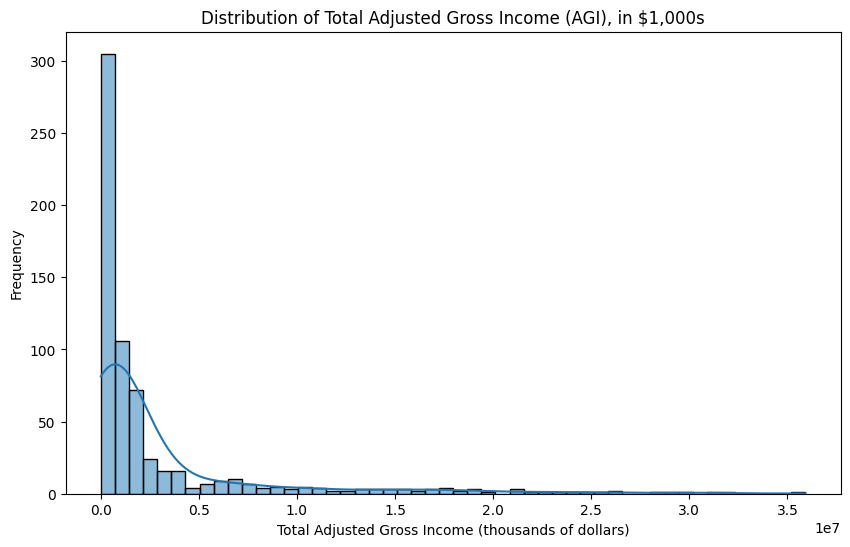

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df_tax['total_adjusted_gross_income_thousands_of_dollars'], bins=50, kde=True)
plt.title('Distribution of Total Adjusted Gross Income (AGI), in $1,000s')
plt.xlabel('Total Adjusted Gross Income (thousands of dollars)')
plt.ylabel('Frequency')
plt.show()

### Average Net Tax vs. Average AGI
Is there a relationship between average AGI and average net tax?

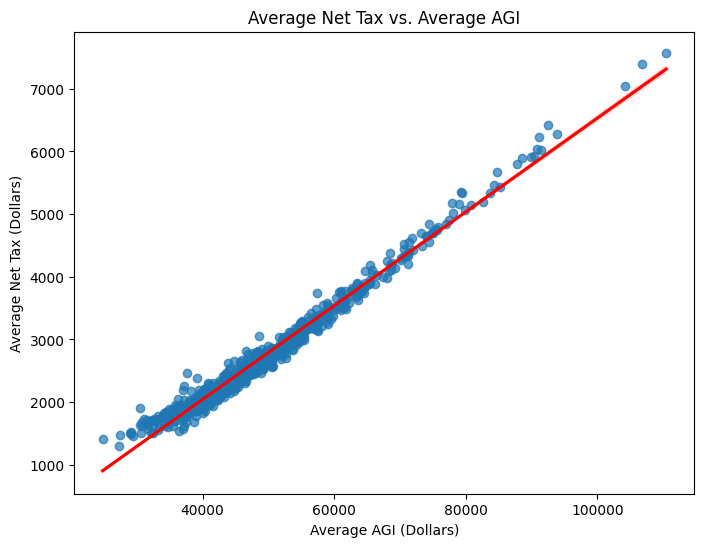

In [51]:
plt.figure(figsize=(8, 6))
sns.regplot(
    x='average_adjusted_gross_income_dollars', 
    y='average_net_tax_dollars', 
    data=df_tax, 
    scatter_kws={'alpha': 0.7}, 
    line_kws={'color': 'red'}
)
plt.title('Average Net Tax vs. Average AGI')
plt.xlabel('Average AGI (Dollars)')
plt.ylabel('Average Net Tax (Dollars)')
plt.show()

### Proportion of Return Types by County
Let's look at the breakdown of return types for several counties.

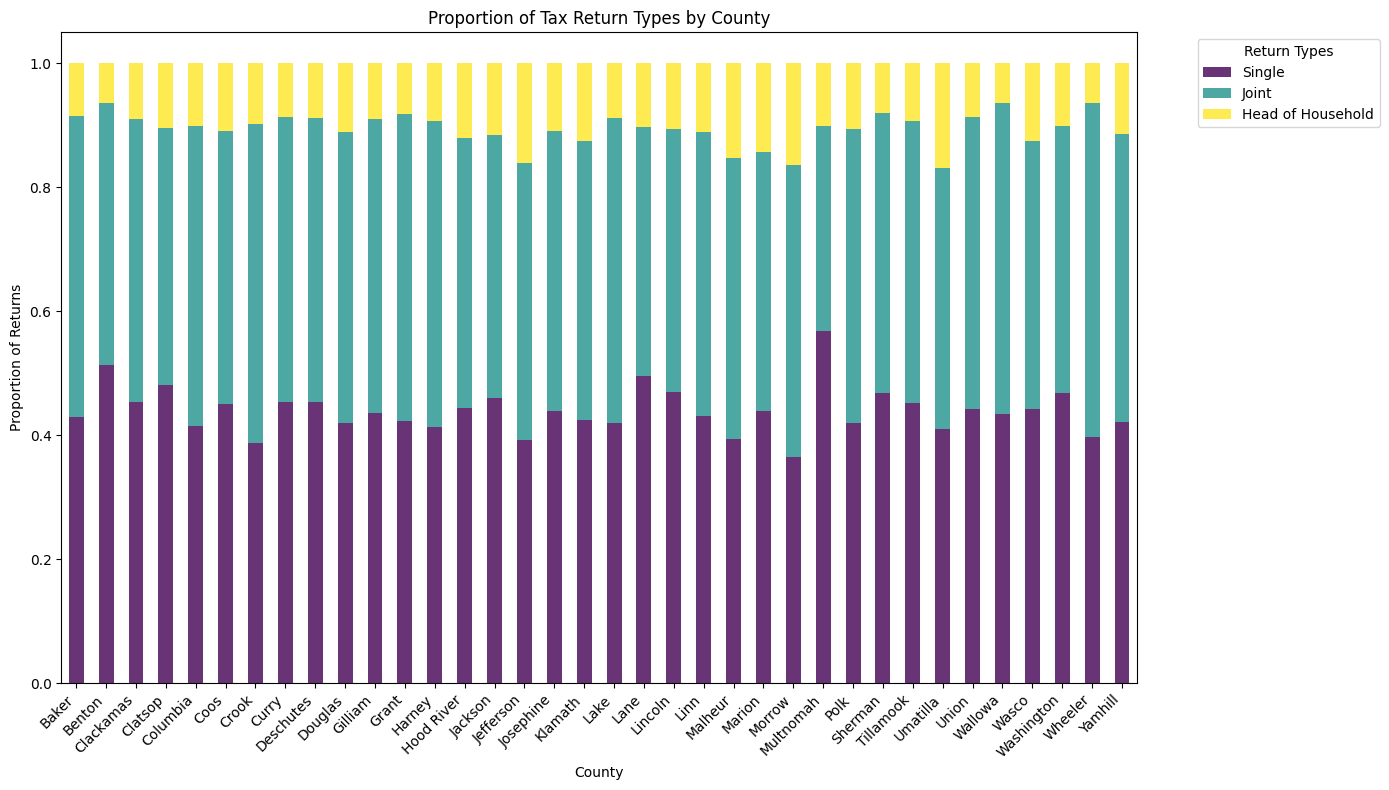

In [52]:
return_types = ['return_type_single_', 'return_type_joint_', 'return_type_head_household_']
return_labels = ['Single', 'Joint', 'Head of Household']

# Calculate the average for each return type by county
averages = df_tax.groupby('county')[return_types].mean()

# Normalize the data to get proportions (sum to 1 for each county)
proportions = averages.div(averages.sum(axis=1), axis=0)

# Plot the stacked bar chart
proportions.plot(kind='bar', stacked=True, figsize=(14, 8), alpha=0.8, colormap='viridis')

# Customize the plot
plt.title('Proportion of Tax Return Types by County')
plt.ylabel('Proportion of Returns')
plt.xlabel('County')
plt.legend(return_labels, title='Return Types', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45, ha='right')  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

### Correlation Matrix
Let's examine correlations among key numeric variables.

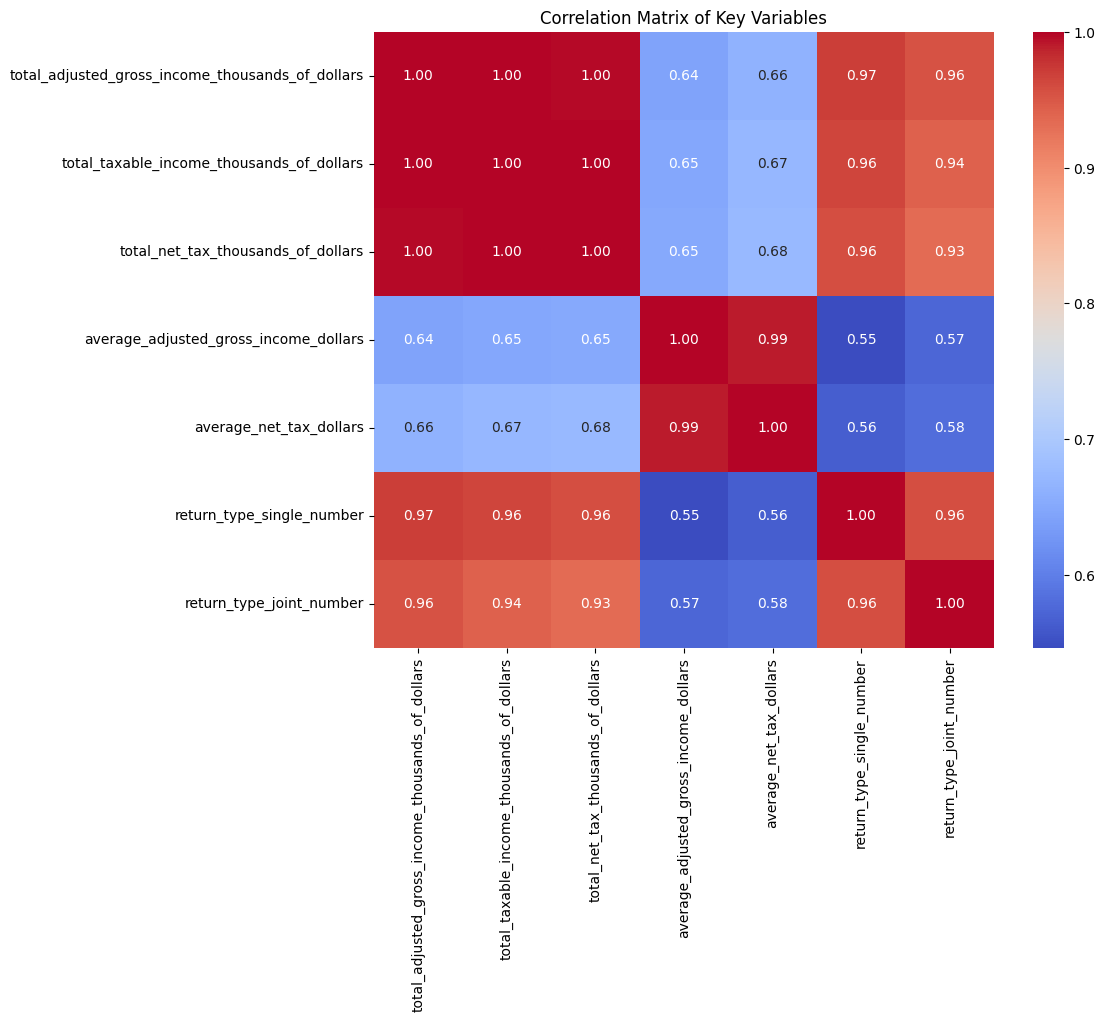

In [53]:
# Select the valid columns for correlation
columns_to_corr = [
    'total_adjusted_gross_income_thousands_of_dollars',
    'total_taxable_income_thousands_of_dollars',
    'total_net_tax_thousands_of_dollars',
    'average_adjusted_gross_income_dollars',
    'average_net_tax_dollars',
    'return_type_single_number',
    'return_type_joint_number'
]

# Compute the correlation matrix
correlation_matrix = df_tax[columns_to_corr].corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Key Variables')
plt.show()

**Observations:**
- AGI and taxable income are highly correlated, as expected which demonstrates the effectiveness of the tax system.
- Average net tax rises with average AGI, but the relationship is not strictly linear—higher incomes may claim more credits or deductions.
- The proportions of return types vary by county and year but in general, the are pretty identical without too much of variations.
- The correlation graph presents to us a lot of valuable relationships between data that will be explored later in the next steps.

## 4. Question Formulation and Answering

### Question 1: Which are the top 5 counties that had the highest average AGI in the latest year available?

In [54]:
# Find the latest year and filter data
latest_year = df_tax['tax_year'].max()
latest = df_tax[df_tax['tax_year'] == latest_year]

# Get top 5 counties with highest average AGI
top_5_counties = latest.nlargest(5, 'average_adjusted_gross_income_dollars')

# Display the results
print(f"Top 5 Counties with Highest Average AGI in {latest_year}:")
print(top_5_counties[['county', 'tax_year', 'average_adjusted_gross_income_dollars']].to_string(index=False))

Top 5 Counties with Highest Average AGI in 2021:
    county  tax_year  average_adjusted_gross_income_dollars
 Clackamas      2021                                 110469
 Deschutes      2021                                 106830
Washington      2021                                 104219
 Multnomah      2021                                  92499
Hood River      2021                                  91184


**Answer:** The top 5 counties with the highest AGI are Clackamas, Deschutes, Washington, Multnomah, and Hood River, which indicates that these are among the richest counties in the state of Oregon. Surprisingly, the differences in amounts are not as much as we would expect from reality, considering that counties like Deschutes and Hood River with smaller populations should be significantly lower than more populated counties like Multnomah or Washington

### Question 2: Which are the 5 counties that had the lowest total net tax collected in the latest year?

In [55]:
# Get the 5 counties with the lowest total net tax
lowest_5_tax_counties = latest.nsmallest(5, 'total_net_tax_thousands_of_dollars')

# Display the results
print(f"Top 5 Counties with Lowest Total Net Tax in {latest_year}:")
print(lowest_5_tax_counties[['county', 'tax_year', 'total_net_tax_thousands_of_dollars']].to_string(index=False))

Top 5 Counties with Lowest Total Net Tax in 2021:
 county  tax_year  total_net_tax_thousands_of_dollars
Wheeler      2021                                2052
Gilliam      2021                                3466
Sherman      2021                                3792
 Harney      2021                                8734
   Lake      2021                                9955


**Answer:** The county with the lowest total net tax collected in the latest year was above. This may indicate a small population or low incomes. This does indeed confirm that the tax data is so far accurate.

### Question 3: What percentage of returns were filed as joint returns in Multnomah County over the years?

In [56]:
multnomah = df_tax[df_tax['county'] == 'Multnomah']
multnomah_joint = multnomah[['tax_year', 'return_type_joint_']].copy()

# Convert decimal to percentage for better readability
multnomah_joint['joint_percentage'] = multnomah_joint['return_type_joint_'] * 100

# Format with 2 decimal places and % symbol
multnomah_joint['formatted_percentage'] = multnomah_joint['joint_percentage'].apply(lambda x: f"{x:.2f}%")

print("Joint Returns Percentage in Multnomah County:")
print(multnomah_joint[['tax_year', 'formatted_percentage']].to_string(index=False))

Joint Returns Percentage in Multnomah County:
 tax_year formatted_percentage
     2004               34.80%
     2005               34.40%
     2006               33.70%
     2007               33.10%
     2008               33.50%
     2009               34.20%
     2010               34.00%
     2011               33.50%
     2012               33.30%
     2013               33.00%
     2014               32.50%
     2015               32.20%
     2016               31.70%
     2017               31.50%
     2018               30.80%
     2019               29.90%
     2020               29.40%
     2021               29.20%


**Answer:** The table shows the percentage of joint returns in Multnomah County by year. There are slight fluctuations, reflecting that the number of single tax filers might have increased over the years. This suggests that there is a smaller married population in recent years compared to the past. This could also indicate that more businesses have been added to the county since its population has grown substantially over the past decade.

### Question 4: How has the average net tax changed over time statewide?

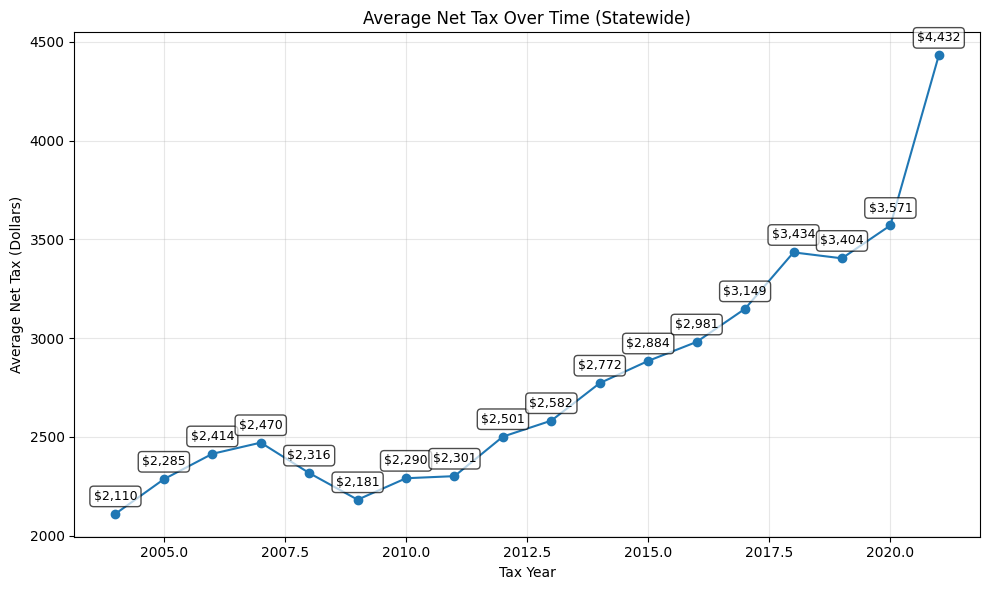

In [57]:
# Plotting the average net tax over time for the entire state
statewide = df_tax.groupby('tax_year').agg({'average_net_tax_dollars':'mean'}).reset_index()

plt.figure(figsize=(10, 6))
plt.plot(statewide['tax_year'], statewide['average_net_tax_dollars'], marker='o')

# Add dollar amount labels on each point
for i, row in statewide.iterrows():
    plt.annotate(f'${row["average_net_tax_dollars"]:,.0f}', 
                 xy=(row['tax_year'], row['average_net_tax_dollars']),
                 xytext=(0, 10),  # Offset the label 10 points above the point
                 textcoords='offset points',
                 ha='center',
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

plt.title('Average Net Tax Over Time (Statewide)')
plt.xlabel('Tax Year')
plt.ylabel('Average Net Tax (Dollars)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** The line chart shows how the average net tax has changed statewide over the years. Trends may reflect economic growth or legislative changes. There is a dip in the graph from 2007 to 2009 reflect the 2009 financial crisis and Great Regression. The recovery starts roughly from 2010 and has been growing strong to more than a 100% grow.There is also a big jump in economy from 2020 which shows us how the Oregon has recovered from the Covid-19 pandemic.

### Question 5: Which county consistently files the highest percentage of itemized returns?

In [58]:
county_itemized = df_tax.groupby('county')['return_type_itemized_'].mean().sort_values(ascending=False).head(5)

# Convert to percentages and display cleanly
print("Top 5 Counties with Highest Itemized Returns:")
for county, value in county_itemized.items():
    print(f"{county}: {value * 100:.2f}%")

Top 5 Counties with Highest Itemized Returns:
Clackamas: 54.25%
Columbia: 53.58%
Deschutes: 52.33%
Polk: 50.87%
Crook: 50.03%


**Answer:** The counties above have the highest average percentage of itemized returns, likely reflecting higher incomes or more deductions. Taxpayers typically itemize when their deductions exceed the standard deduction. This often correlates with higher incomes and more complex financial situations. Mortgage interest and property taxes are major itemized deductions thus, this data shows that there are significant homeownership in these counties. This also suggests that these areas might have higher housing costs, property taxes, and state/local taxes. 

### Question 6: What is the correlation between the percent of joint returns and average AGI?

In [59]:
joint_agi_corr = df_tax['return_type_joint_'].corr(df_tax['average_adjusted_gross_income_dollars'])

print("Correlation Analysis")
print("=" * 40)
print(f"Joint Returns % vs Average AGI: {joint_agi_corr:.4f}")
print()

Correlation Analysis
Joint Returns % vs Average AGI: -0.6049



**Answer:** The correlation coefficient is shown above. With a negative correlation of -0.6270, we can conclude that higher income areas have fewer joint tax fillers. This indicates that there are more single highe earner in the wealthy areas. This also suggests that there might be some tax filing strategy being used with high income filers regardless of their marital status (married filing separately).

### Question 7: Is there a county where head of household returns make up a particularly large share?

In [60]:
# Get top 5 counties with highest Head of Household percentages
top_5_hoh = df_tax.nlargest(5, 'return_type_head_household_')

print("Top 5 Counties with Highest Head of Household Returns:")
print("=" * 55)

for i, (_, row) in enumerate(top_5_hoh.iterrows(), 1):
    print(f"{i}. {row['county']} ({row['tax_year']}): {row['return_type_head_household_'] * 100:.2f}%")

print("\n" + "=" * 55)

# Get bottom 5 counties with lowest Head of Household percentages
bottom_5_hoh = df_tax.nsmallest(5, 'return_type_head_household_')

print("Top 5 Counties with Lowest Head of Household Returns:")
print("=" * 55)

for i, (_, row) in enumerate(bottom_5_hoh.iterrows(), 1):
    print(f"{i}. {row['county']} ({row['tax_year']}): {row['return_type_head_household_'] * 100:.2f}%")

Top 5 Counties with Highest Head of Household Returns:
1. Morrow (2012): 18.70%
2. Morrow (2014): 18.70%
3. Jefferson (2004): 18.50%
4. Morrow (2015): 18.20%
5. Morrow (2013): 17.90%

Top 5 Counties with Lowest Head of Household Returns:
1. Wheeler (2005): 5.30%
2. Wheeler (2016): 5.30%
3. Wheeler (2006): 5.60%
4. Wheeler (2009): 5.80%
5. Benton (2015): 5.90%


**Answer:** This comparison between highest vs lowest Head of Household Returns shows an interesting fact that the counties from both are rural and small counties. This suggests that urban location or population does not have any impact to the family structure reflected by the return type of Head of Household Returns.

### Question 8: What is the trend in number of returns filed in the three most populous counties?

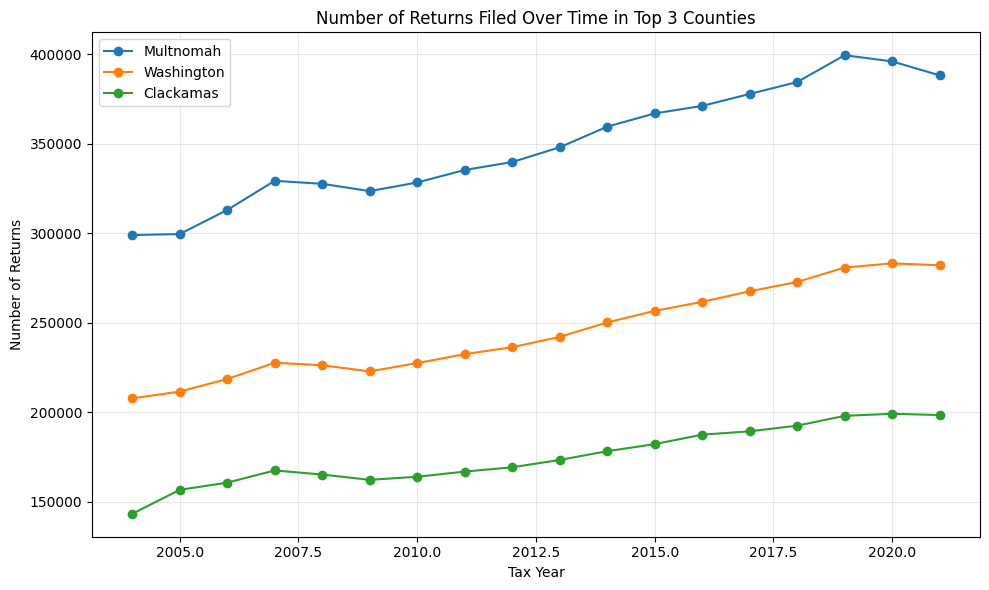

In [61]:
top3_counties = df_tax.groupby('county')['number_of_returns'].mean().sort_values(ascending=False).head(3).index.tolist()

plt.figure(figsize=(10, 6))
for county in top3_counties:
    county_df = df_tax[df_tax['county'] == county]
    plt.plot(county_df['tax_year'], county_df['number_of_returns'], marker='o', label=county)

plt.title('Number of Returns Filed Over Time in Top 3 Counties')
plt.xlabel('Tax Year')
plt.ylabel('Number of Returns')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

**Answer:** The graph realistically reflects that these 3 counties are among the largest in population as well as economy in Oregon. The graph shows very uniform growth among the 3 counties. The slight decline during 2008 is also reflected in the graph, which suggests the accuracy of this data compared to reality. One notable fact about the trends is that Multnomah seems to start declining after 2019, suggesting that the county has reached its full potential since it is one of the older urban areas and the economy seems to be shifting more toward newer urban areas like Washington or Clackamas, which are still growing steadily after 2019.

### Question 9: What is the relationship between total gross tax and total net tax?

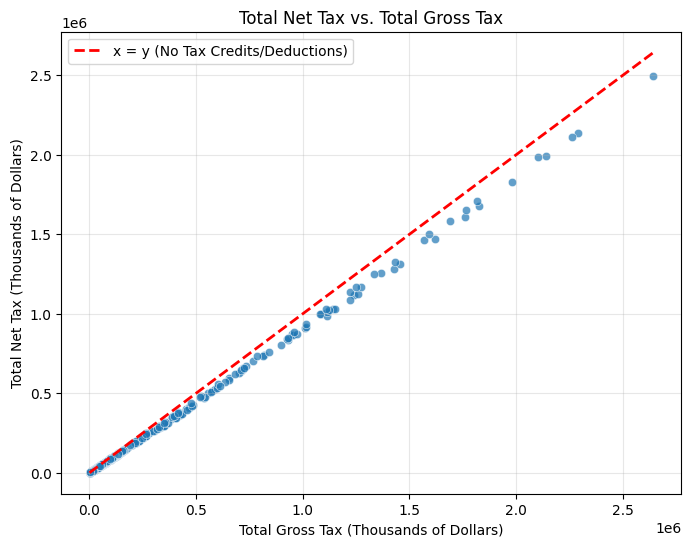

In [62]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x='total_gross_tax_thousands_of_dollars', 
                y='total_net_tax_thousands_of_dollars', 
                data=df_tax, 
                alpha=0.7)

# Add diagonal line (x = y) for comparison
max_value = max(df_tax['total_gross_tax_thousands_of_dollars'].max(), 
                df_tax['total_net_tax_thousands_of_dollars'].max())
plt.plot([0, max_value], [0, max_value], 'r--', linewidth=2, label='x = y (No Tax Credits/Deductions)')

plt.title('Total Net Tax vs. Total Gross Tax')
plt.xlabel('Total Gross Tax (Thousands of Dollars)')
plt.ylabel('Total Net Tax (Thousands of Dollars)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

**Answer:** The scatterplot shows a strong positive relationship between gross and net tax, as expected. The points form a nearly perfect straight line from bottom-left to top-right. This indicates that there is an extremely strong positive correlation between Total Gross Tax and Total Net Tax. This suggests that Oregon's tax system is very consistent across all counties. With the red diagonal line where x = y, we can see that Net Tax is always less than Gross Tax (points are below the diagonal). The gap seems to slightly widen with higher income, indicating that there might be higher tax rates applied to higher income earners.

### Question 10: Which county has the highest average tax as a percentage of AGI, and what might this indicate?

In [63]:
# Calculate tax as percentage of AGI
df_tax['tax_pct_agi'] = (df_tax['average_net_tax_dollars'] / df_tax['average_adjusted_gross_income_dollars']) * 100

# Get top 5 counties and display nicely
top_5_counties = df_tax.groupby('county')['tax_pct_agi'].mean().sort_values(ascending=False).head(5)

print("Top 5 Counties with Highest Tax as % of AGI:")
print("=" * 45)
for i, (county, pct) in enumerate(top_5_counties.items(), 1):
    print(f"{i}. {county}: {pct:.2f}%")

Top 5 Counties with Highest Tax as % of AGI:
1. Washington: 6.26%
2. Multnomah: 6.23%
3. Clackamas: 6.21%
4. Benton: 5.96%
5. Deschutes: 5.95%


**Answer:** The counties with the highest tax rates are indeed among the highest-ranking in terms of economy in the state. This suggests that urban areas tend to have higher tax rates, reflecting higher income tax brackets. In addition, this also indicates higher tax rates for property as well.

## 5. Conclusion

**Summary of Findings:**
- There are many differences in income, tax, and filing behavior across Oregon counties to explore.
- Some counties consistently report higher average incomes and tax, while others are lower but relatively growing.
- The Analysis shows that Oregon tax regulation is indeed very consistent and progressively applicable across the counties and income range.
- Data collected seem to be accurately reflecting the economy of each county. More urban counties do report to have higher income tax return compared to more rural ones.
- Interesting finding is that rural counties are amongst the highest rate of having head of the household return type.
- Distribution of Total Adjusted Gross Income graph indicates that most economic activity is concentrated in a few large counties. The right skewed graph also indicates that there are very few counties have total AGI above $10 million.
- Proportion of Tax Return Types by County graph shows that number of individual vs joint filers are very similar. This might indicate that there are still a good amount of young population in oregon.
- in general, this data seems to be very accurate and insightful with a lot of valuable data to explore.

**Limitations:**
- The data has other counties that are not from Oregon which affect the over all analysis.
- Outliers or reporting inconsistencies could affect results.
- Some fields have missing values that could impact more granular analysis.

**Reflection:**
- This project provided experience in all steps of the data analysis process, from cleaning and EDA to analyzing it.
- The data is large enough and does have garbage data that I was able to apply a lot of the methods learned from this class to help cleaning them up nicely for my analysis. 
- One of the biggest challenge is to look at the data and decide on what to analyze. Picking the right data to analyze is a very crucial part of the project.
- There are more data from this set to explore in the future besides the obvious ones that I did for this report, but for the simplicity and cleanliness of this project, I decide only to explore on the main data to make it easier to demonstrate my finding versus what we perceive from living in Oregon.